In [1]:
# Import libraries

# Standard Python libraries
import os
import json
import re
from pathlib import Path
from collections import Counter

# Data handling
import pandas as pd
import numpy as np

# Progress bar
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Structured outputs
from pydantic import BaseModel, Field

# LLM
from langchain_groq import ChatGroq

# Kaggle dataset download
import kagglehub

#### Initializing the LLM

In [34]:
# Initialise the LLM (here, using Groq API)

import os
import langchain_groq
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = "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"
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
)

In [36]:
test_response = llm.invoke("Reply with the word: working") # test the LLM
print(test_response.content)

working


#### Reddit dataset extraction

In [3]:
# Reddit dataset

handle = "entenam/reddit-mental-health-dataset"

dataset_dir = Path(
    kagglehub.dataset_download(handle)
)

csv_files = sorted(
    dataset_dir.rglob("*.csv")
)

df = pd.read_csv(
    csv_files[0],
    low_memory=False
)

#### Data inspection

In [4]:
# Dataset inspection

print(f"Number of posts: {len(df):,}")

print("\nColumns:") #score, selftext, subreddit, title, label
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nExample narrative:\n") # the first example of the self narrative
print(df.loc[0, "selftext"])

Number of posts: 223

Columns:
['score', 'selftext', 'subreddit', 'title', 'Label']

Missing values:
score        23
selftext     23
subreddit    23
title        23
Label        23
dtype: int64

Example narrative:

Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education. I’m also an alcoholic cause that helps me forget about shit. But watching this and these people have anxiety, while they have an education and a license and shit. Not saying no one can have anxiety, but if someone with a life can’t get over anxiety how do I have a chance... Like I’m so much further behind these people that are so lost they made a documentary about them. Am I past the point of lost?


In [5]:
# We want to only analyse the narratives.

# Metadata (score, title, subreddit...) are intentionally excluded because the aim of the project
# is to only investigate the content of self-reported experiences.

texts = (
    df["selftext"]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"\nNarratives available: {len(texts):,}")


Narratives available: 200


# Structured output schemas

In [6]:
# LLM free-text responses are difficult to analyse systematically. Every stage of the workflow here is
# thus constrained using Pydantic schemas. Each information could in this way be aggregated, visualized and reused in later stages.

### Narrative analysis

In [7]:
# Observable characteristics of each narrative without attempting to infer psychological mechanisms.

class NarrativeAnalysis(BaseModel):

    emotions: list[str]

    challenges: list[str]

    contextual_factors: list[str]

    therapeutic_needs: list[str]

### Behavioural mechanism analysis

In [8]:
# Behavioural mechanisms are inferred from the narratives. An explanation is produced.

In [9]:
class BehaviouralAnalysis(BaseModel):

    mechanisms: list[str]

    explanation: str

### Intervention mapping

In [10]:
# Based on the inferred behavioural mechanisms, the model proposes evidence-informed psychological interventions.

In [11]:
class Intervention(BaseModel):

    name: str

    rationale: str

    target_mechanisms: list[str]


class InterventionSuggestion(BaseModel):

    interventions: list[Intervention]

#### Evidence traceability

In [12]:
# Improving transparency by documenting which parts of the text motivated the generated outputs.

In [13]:
class EvidenceQuote(BaseModel):

    quote: str

    interpretation: str


class EvidenceTrace(BaseModel):

    supporting_evidence: list[EvidenceQuote]

    explanation: str

### Research hypotheses generation

In [14]:
# This generates testable hypotheses that could be used for future empirical research.

In [15]:
class Hypothesis(BaseModel):

    hypothesis: str

    rationale: str

    supporting_patterns: list[str]

    supporting_evidence: list[EvidenceQuote]

    research_value: str


class ResearchHypothesis(BaseModel):

    hypotheses: list[Hypothesis]

# Helper functions

In [16]:
def clean_json(response): # clean the first-person narratives

    response = response.strip()

    response = re.sub(
        r"^```json",
        "",
        response,
        flags=re.IGNORECASE
    )

    response = re.sub(
        r"^```",
        "",
        response
    )

    response = re.sub(
        r"```$",
        "",
        response
    )

    return response.strip()

In [17]:
def call_llm(prompt): # function for calling the LLM

    response = llm.invoke(prompt)

    return response.content

def run_analysis(prompt, schema): # generic analysis function

    response = call_llm(prompt)

    response = clean_json(response)

    return schema.model_validate_json(response)

#### Function for outputs saving

In [19]:
def save_json(data, filename):

    os.makedirs("outputs", exist_ok=True)

    filepath = os.path.join(
        "outputs",
        filename
    )

    with open(filepath, "w") as f:

        json.dump(
            data,
            f,
            indent=4,
            ensure_ascii=False
        )

    print(f"Saved: {filepath}")

In [20]:
def save_csv(df, filename):

    os.makedirs("outputs", exist_ok=True)

    filepath = os.path.join(
        "outputs",
        filename
    )

    df.to_csv(
        filepath,
        index=False
    )

    print(f"Saved: {filepath}")

In [21]:
# output folders

folders = [

    "outputs",

    "figures"

]

for folder in folders:

    os.makedirs(
        folder,
        exist_ok=True
    )

# AGENTS

## Narrative analysis (1st step)

In [23]:
# descriptive qualitative coding of the original narrative

In [24]:
def analyse_narrative(text):

    prompt = f"""
You are assisting with qualitative mental health research.

Analyse the following first-person narrative describing a lived experience
of mental health difficulties.

The objective is descriptive qualitative coding, not diagnosis.

Identify:

1. emotions expressed in the narrative;
2. central challenges described by the author;
3. contextual factors that may influence the person's experience;
4. therapeutic or support needs expressed or reasonably implied by the text.

Use only information supported by the narrative.

Return one valid JSON object with exactly the following structure:

{{
    "emotions": [],
    "challenges": [],
    "contextual_factors": [],
    "therapeutic_needs": []
}}

Do not include Markdown formatting or explanatory text outside the JSON object.

Narrative:

{text}
"""

    analysis = run_analysis(
        prompt,
        NarrativeAnalysis
    )

    return analysis

In [37]:
# initial testing on one narrative

sample_text = texts[0]

narrative_analysis = analyse_narrative(
    sample_text
)

print(narrative_analysis)

emotions=['frustration', 'despair', 'hopelessness', 'helplessness', 'anxiety'] challenges=['lack of future prospects', 'financial struggles', 'limited access to education', 'alcoholism as a coping mechanism'] contextual_factors=['socioeconomic status', 'access to education and resources'] therapeutic_needs=['hope and motivation', 'support for overcoming anxiety', 'addressing underlying issues driving alcoholism', 'practical assistance with education and career goals']


In [ ]:
print("EMOTIONS")

for emotion in narrative_analysis.emotions:
    print("-", emotion)


print("\nCHALLENGES")

for challenge in narrative_analysis.challenges:
    print("-", challenge)


print("\nCONTEXTUAL FACTORS")

for factor in narrative_analysis.contextual_factors:
    print("-", factor)


print("\nTHERAPEUTIC NEEDS")

for need in narrative_analysis.therapeutic_needs:
    print("-", need)

EMOTIONS
- frustration
- despair
- hopelessness
- helplessness
- anxiety

CHALLENGES
- lack of future prospects
- financial struggles
- limited access to education
- alcoholism as a coping mechanism

CONTEXTUAL FACTORS
- socioeconomic status
- access to education and resources

THERAPEUTIC NEEDS
- hope and motivation
- support for overcoming anxiety
- addressing underlying issues driving alcoholism
- practical assistance with education and career goals


## Behavioural mechanisms analysis (2nd step)

In [39]:
def analyse_behaviour(narrative):

    # The LLM reasons on alredy coded representations.

    narrative_json = json.dumps(
        narrative.model_dump(),
        indent=2
    )

    prompt = f"""
You are assisting with qualitative mental health research.

The following narrative has already been coded into structured categories.

Your task is to infer behavioural mechanisms that may contribute to the
reported experiences.

The objective is interpretation rather than diagnosis.

Behavioural mechanisms may include examples such as:

- avoidance
- rumination
- reassurance seeking
- emotional suppression
- hypervigilance
- self-medication
- catastrophising
- social withdrawal

Use only information supported by the structured narrative.

Return exactly one JSON object.

{{
    "mechanisms": [],
    "explanation": ""
}}

Structured narrative:

{narrative_json}
"""

    behavioural_analysis = run_analysis(
        prompt,
        BehaviouralAnalysis
    )

    return behavioural_analysis

In [40]:
behavioural_analysis = analyse_behaviour( # test
    narrative_analysis
)

print(behavioural_analysis)

mechanisms=['rumination', 'self-medication', 'catastrophising', 'avoidance', 'social withdrawal'] explanation="The participant's experiences of frustration, despair, hopelessness, helplessness, and anxiety are likely exacerbated by their lack of future prospects, financial struggles, and limited access to education. These challenges may lead to rumination about their circumstances, catastrophising about their future, and avoidance of situations that trigger feelings of anxiety. The use of alcohol as a coping mechanism (self-medication) may provide temporary relief but ultimately perpetuates a cycle of dependency and social withdrawal. The participant's socioeconomic status and limited access to education and resources may further contribute to their feelings of hopelessness and helplessness, making it essential to address these underlying issues in therapy."


In [41]:
print("IDENTIFIED MECHANISMS\n")

for mechanism in behavioural_analysis.mechanisms:

    print("-", mechanism)

print("\nInterpretation\n")

print(behavioural_analysis.explanation)

IDENTIFIED MECHANISMS

- rumination
- self-medication
- catastrophising
- avoidance
- social withdrawal

Interpretation

The participant's experiences of frustration, despair, hopelessness, helplessness, and anxiety are likely exacerbated by their lack of future prospects, financial struggles, and limited access to education. These challenges may lead to rumination about their circumstances, catastrophising about their future, and avoidance of situations that trigger feelings of anxiety. The use of alcohol as a coping mechanism (self-medication) may provide temporary relief but ultimately perpetuates a cycle of dependency and social withdrawal. The participant's socioeconomic status and limited access to education and resources may further contribute to their feelings of hopelessness and helplessness, making it essential to address these underlying issues in therapy.


## Intervention mapping (3rd step)

In [42]:
# exploring which psychological interventions could address reported difficulties

In [43]:
def map_interventions(behavioural_analysis):

    behavioural_json = json.dumps(
        behavioural_analysis.model_dump(),
        indent=2,
        ensure_ascii=False
    )

    prompt = f"""
You are assisting with qualitative mental health research.

The following behavioural mechanisms were identified from a person's
self-reported experience.

Suggest psychological intervention approaches that could potentially
address these mechanisms.

Examples include:

- Cognitive Behavioural Therapy (CBT)
- Acceptance and Commitment Therapy (ACT)
- Dialectical Behaviour Therapy (DBT)
- Behavioural Activation
- Mindfulness-Based Cognitive Therapy
- Exposure Therapy
- Motivational Interviewing
- Psychoeducation
- Social Skills Training
- Self-Compassion interventions

For every intervention explain briefly why it may be appropriate.

Do not recommend medication.

The interventions should be interpreted as possible research directions,
not clinical recommendations.

Return one valid JSON object:

{{
    "interventions": [
        {{
            "name": "",
            "rationale": "",
            "target_mechanisms": []
        }}
    ]
}}

Do not include Markdown.

Behavioural mechanisms:

{behavioural_json}
"""

    intervention_analysis = run_analysis(
        prompt,
        InterventionSuggestion
    )

    return intervention_analysis

In [45]:
intervention_analysis = map_interventions( # test
    behavioural_analysis
)

intervention_analysis.model_dump()

{'interventions': [{'name': 'Cognitive Behavioural Therapy (CBT)',
   'rationale': 'CBT can help the participant identify and challenge negative thought patterns, such as rumination and catastrophising, and replace them with more balanced and constructive ones.',
   'target_mechanisms': ['rumination', 'catastrophising']},
  {'name': 'Acceptance and Commitment Therapy (ACT)',
   'rationale': 'ACT can help the participant develop psychological flexibility and acceptance of their thoughts and emotions, reducing rumination and avoidance.',
   'target_mechanisms': ['rumination', 'avoidance']},
  {'name': 'Dialectical Behaviour Therapy (DBT)',
   'rationale': 'DBT can help the participant develop skills to manage emotions and reduce self-medication, as well as improve relationships and reduce social withdrawal.',
   'target_mechanisms': ['self-medication', 'social withdrawal']},
  {'name': 'Behavioural Activation',
   'rationale': 'Behavioural Activation can help the participant increase eng

In [46]:
print("SUGGESTED INTERVENTIONS")

for intervention in intervention_analysis.interventions:

    print("\nIntervention")
    print(intervention.name)

    print("Why?")
    print(intervention.rationale)

    print("Targets")

    for mechanism in intervention.target_mechanisms:
        print("-", mechanism)

SUGGESTED INTERVENTIONS

Intervention
Cognitive Behavioural Therapy (CBT)
Why?
CBT can help the participant identify and challenge negative thought patterns, such as rumination and catastrophising, and replace them with more balanced and constructive ones.
Targets
- rumination
- catastrophising

Intervention
Acceptance and Commitment Therapy (ACT)
Why?
ACT can help the participant develop psychological flexibility and acceptance of their thoughts and emotions, reducing rumination and avoidance.
Targets
- rumination
- avoidance

Intervention
Dialectical Behaviour Therapy (DBT)
Why?
DBT can help the participant develop skills to manage emotions and reduce self-medication, as well as improve relationships and reduce social withdrawal.
Targets
- self-medication
- social withdrawal

Intervention
Behavioural Activation
Why?
Behavioural Activation can help the participant increase engagement in activities and improve mood, reducing avoidance and social withdrawal.
Targets
- avoidance
- social

## Evidence traceability (4th step)

In [53]:
# making the decision of the LLM for the interventions and the annotated behavioural mechanisms transparent by examining the narrative and behavioural mechanisms

In [47]:
def trace_evidence(text, behavioural_analysis, intervention_analysis):

    behavioural_json = json.dumps(
        behavioural_analysis.model_dump(),
        indent=2,
        ensure_ascii=False
    )

    intervention_json = json.dumps(
        intervention_analysis.model_dump(),
        indent=2,
        ensure_ascii=False
    )

    prompt = f"""
You are assisting with qualitative mental health research.

The original first-person narrative is provided below, together with the
behavioural mechanisms and psychological interventions generated in earlier
stages of the analysis.

Your task is to explain why these interventions were generated.

For each supporting quote:

1. copy an exact excerpt from the original narrative;
2. explain how the quote supports one or more identified behavioural
   mechanisms or suggested interventions.

Do not invent quotations.
Do not use information that is not present in the narrative.
Do not provide diagnosis or treatment advice.

Return one valid JSON object with exactly this structure:

{{
    "supporting_evidence": [
        {{
            "quote": "",
            "interpretation": ""
        }}
    ],
    "explanation": ""
}}

The final explanation should summarise how the evidence, behavioural mechanisms
and intervention suggestions are connected.

Do not include Markdown or text outside the JSON object.

Original narrative:

{text}

Behavioural analysis:

{behavioural_json}

Intervention mapping:

{intervention_json}
"""

    evidence_analysis = run_analysis(
        prompt,
        EvidenceTrace
    )

    return evidence_analysis

In [49]:
# test

In [50]:
evidence_analysis = trace_evidence(
    sample_text,
    behavioural_analysis,
    intervention_analysis
)

evidence_analysis.model_dump()

{'supporting_evidence': [{'quote': 'Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education.',
   'interpretation': 'This quote supports the behavioural mechanisms of catastrophising and rumination. The participant is catastrophising about their future and feeling hopeless about their ability to overcome anxiety due to their lack of resources and education. They are also ruminating about their circumstances, feeling frustrated and despairing about their situation.'},
  {'quote': 'I’m also an alcoholic cause that helps me forget about shit.',
   'interpretation': 'This quote supports the behavioural mechanism of self-medication. The participant is using alcohol as a coping mechanism to forget about their problems, indicating a reliance on substance use to manage their emotions and

In [51]:
print("SUPPORTING EVIDENCE")

for item in evidence_analysis.supporting_evidence:

    print("\nQuote:")
    print(item.quote)

    print("Why it matters:")
    print(item.interpretation)


print("\nOVERALL EXPLANATION")
print(evidence_analysis.explanation)

SUPPORTING EVIDENCE

Quote:
Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education.
Why it matters:
This quote supports the behavioural mechanisms of catastrophising and rumination. The participant is catastrophising about their future and feeling hopeless about their ability to overcome anxiety due to their lack of resources and education. They are also ruminating about their circumstances, feeling frustrated and despairing about their situation.

Quote:
I’m also an alcoholic cause that helps me forget about shit.
Why it matters:
This quote supports the behavioural mechanism of self-medication. The participant is using alcohol as a coping mechanism to forget about their problems, indicating a reliance on substance use to manage their emotions and avoid dealing with their issues

## Research hypotheses generation (last stage)

In [54]:
# the decision for the research hypothesis should be made transparent

In [55]:
def generate_hypotheses(summary):

    summary_json = json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )

    prompt = f"""
You are assisting with qualitative mental health research.

The following summary contains recurring patterns extracted from a collection
of first-person mental health narratives.

Your task is to generate four distinct exploratory research hypotheses.

The hypotheses should focus on possible relationships between:

- reported emotional or behavioural difficulties,
- coping patterns,
- therapeutic needs,
- possible intervention targets.

Do not compare treatment effectiveness.
Do not claim causality.
Do not present the hypotheses as established findings.

For each hypothesis provide:

1. a clear hypothesis;
2. a rationale explaining why it emerged from the qualitative findings;
3. the recurring patterns that support it;
4. selected evidence examples;
5. a short explanation of its potential research value.

Each evidence example must include:

- an exact quote;
- an interpretation explaining why the quote is relevant.

Return one valid JSON object with exactly this structure:

{{
    "hypotheses": [
        {{
            "hypothesis": "",
            "rationale": "",
            "supporting_patterns": [],
            "supporting_evidence": [
                {{
                    "quote": "",
                    "interpretation": ""
                }}
            ],
            "research_value": ""
        }}
    ]
}}

The hypotheses list should contain four items.

Do not include Markdown or text outside the JSON object.

Aggregated findings:

{summary_json}
"""

    hypothesis_analysis = run_analysis(
        prompt,
        ResearchHypothesis
    )

    return hypothesis_analysis

# Running the workflow

In [59]:
number_of_cases = 10 # smaller sample, if using an open-source LLM

analysis_texts = texts[:number_of_cases]

print(f"Number of narratives selected: {len(analysis_texts)}") # test

Number of narratives selected: 10


In [60]:
results = []
failed_cases = []


for i, text in enumerate(
    tqdm(
        analysis_texts,
        total=len(analysis_texts)
    )
):

    # One dictionary is created for each narrative and gradually updated as
    # the analysis proceeds through the different stages.

    case_analysis = {
        "id": i,
        "text": text
    }

    try:

        # Descriptive qualitative coding of the original narrative
        narrative = analyse_narrative(
            text
        )

        case_analysis["narrative"] = (
            narrative.model_dump()
        )


        # Interpretation of possible behavioural mechanisms
        behavioural = analyse_behaviour(
            narrative
        )

        case_analysis["behavioural"] = (
            behavioural.model_dump()
        )


        # Mapping mechanisms to potential intervention approaches
        interventions = map_interventions(
            behavioural
        )

        case_analysis["intervention"] = (
            interventions.model_dump()
        )


        # Trace the intervention suggestions back to the source narrative
        evidence = trace_evidence(
            text,
            behavioural,
            interventions
        )

        case_analysis["evidence"] = (
            evidence.model_dump()
        )


        # Add the completed analysis to the results
        results.append(
            case_analysis
        )


    except Exception as error:

        # A failed API call or invalid model response is stored separately.
        # This allows the remaining narratives to continue processing.

        failed_case = {
            "id": i,
            "text": text,
            "error": str(error)
        }

        failed_cases.append(
            failed_case
        )

        print(
            f"\nFailed case {i}: {error}"
        )

 30%|███       | 3/10 [00:58<02:44, 23.55s/it]


Failed case 2: 1 validation error for EvidenceTrace
  Invalid JSON: EOF while parsing an object at line 24 column 773 [type=json_invalid, input_value='{\n  "supporting_evidenc...d social interactions."', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid


 70%|███████   | 7/10 [03:38<01:50, 37.00s/it]


Failed case 6: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kz3ckwmweh38fbwctqsbwswv` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 3968, Requested 2427. Please try again in 3.949999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


100%|██████████| 10/10 [05:21<00:00, 32.15s/it]


In [61]:
print("\nAnalysis complete")

print(
    "Successful cases:",
    len(results)
)

print(
    "Failed cases:",
    len(failed_cases)
)


Analysis complete
Successful cases: 8
Failed cases: 2


In [65]:
# one failed due to API error, the other one due to some error in code (needs to be further explored)

In [64]:
# result inspection
print("ORIGINAL NARRATIVE\n")
print(results[0]["text"])

print("\nNARRATIVE ANALYSIS\n")
print(results[0]["narrative"])

print("\nBEHAVIOURAL ANALYSIS\n")
print(results[0]["behavioural"])

print("\nINTERVENTION MAPPING\n")
print(results[0]["intervention"])

print("\nEVIDENCE TRACE\n")
print(results[0]["evidence"])

ORIGINAL NARRATIVE

Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education. I’m also an alcoholic cause that helps me forget about shit. But watching this and these people have anxiety, while they have an education and a license and shit. Not saying no one can have anxiety, but if someone with a life can’t get over anxiety how do I have a chance... Like I’m so much further behind these people that are so lost they made a documentary about them. Am I past the point of lost?

NARRATIVE ANALYSIS

{'emotions': ['frustration', 'despair', 'hopelessness', 'helplessness', 'anxiety'], 'challenges': ['lack of future prospects', 'financial struggles', 'limited access to education', 'alcoholism as a coping mechanism'], 'contextual_factors': ['socioeconomic status', 'access to education and 

In [69]:
# result saving (successful and unsuccessful separately)
save_json(
    results,
    "case_analyses.json"
)

save_json(
    failed_cases,
    "failed_cases.json"
)

Saved: outputs/case_analyses.json
Saved: outputs/failed_cases.json


## Aggregation of findings

In [70]:
# therapeutic needs

In [72]:
therapeutic_needs = []


for case in results:

    narrative = case.get(
        "narrative"
    )

    if narrative is None:
        continue

    case_needs = narrative.get(
        "therapeutic_needs",
        []
    )

    therapeutic_needs.extend(
        case_needs
    )


need_counts = Counter(
    therapeutic_needs
)

print("Frequency of therapeutic needs:\n")

for need, frequency in need_counts.most_common(20):

    print(
        frequency,
        "-",
        need
    )

Frequency of therapeutic needs:

1 - hope and motivation
1 - support for overcoming anxiety
1 - addressing underlying issues driving alcoholism
1 - practical assistance with education and career goals
1 - emotional support
1 - understanding from others
1 - distraction techniques
1 - coping strategies
1 - effective therapy
1 - management of symptoms
1 - improvement in quality of life
1 - strategies for managing anxiety in social situations
1 - help with reducing self-criticism and shame
1 - support for developing healthier coping mechanisms
1 - healthy coping mechanisms
1 - trust-building
1 - anxiety management techniques
1 - self-care support
1 - alcohol dependence support
1 - ongoing support


In [73]:
# behavioural mechanisms

In [74]:
behavioural_mechanisms = []


for case in results:

    behavioural = case.get(
        "behavioural"
    )

    if behavioural is None:
        continue

    case_mechanisms = behavioural.get(
        "mechanisms",
        []
    )

    behavioural_mechanisms.extend(
        case_mechanisms
    )


mechanism_counts = Counter(
    behavioural_mechanisms
)

print("Frequency of behavioural mechanisms:\n")

for mechanism, frequency in mechanism_counts.most_common(20):

    print(
        frequency,
        "-",
        mechanism
    )

Frequency of behavioural mechanisms:

4 - rumination
4 - avoidance
3 - self-medication
2 - emotional suppression
2 - hypervigilance
1 - catastrophising
1 - social withdrawal
1 - avoidance (avoiding triggers, such as alcohol)
1 - rumination (overthinking)
1 - reassurance seeking (not explicitly stated, but implied through the need for strategies to manage anxiety in social situations)
1 - emotional suppression (not explicitly stated, but implied through the presence of shame and self-doubt)
1 - hypervigilance (not explicitly stated, but implied through the need for strategies to manage anxiety in social situations)
1 - self-medication (avoiding triggers, such as alcohol)
1 - catastrophising (overthinking)
1 - social withdrawal (social anxiety)
1 - avoidance (of social situations)
1 - rumination (on trust issues and anxiety)
1 - reassurance seeking (dependence on alcohol)
1 - emotional suppression (of desperation and frustration)
1 - hypervigilance (in social environments)


In [75]:
# suggested interventions

In [77]:
suggested_interventions = []


for case in results:

    intervention_analysis = case.get(
        "intervention"
    )

    if intervention_analysis is None:
        continue

    case_interventions = intervention_analysis.get(
        "interventions",
        []
    )

    for intervention in case_interventions:

        name = intervention.get(
            "name"
        )

        if name:
            suggested_interventions.append(
                name
            )


intervention_counts = Counter(
    suggested_interventions
)

print("Frequency of intervention approaches:\n")

for intervention, frequency in intervention_counts.most_common(20):

    print(
        frequency,
        "-",
        intervention
    )

Frequency of intervention approaches:

8 - Cognitive Behavioural Therapy (CBT)
8 - Acceptance and Commitment Therapy (ACT)
8 - Dialectical Behaviour Therapy (DBT)
8 - Behavioural Activation
8 - Mindfulness-Based Cognitive Therapy
8 - Exposure Therapy
8 - Motivational Interviewing
8 - Psychoeducation
8 - Social Skills Training
8 - Self-Compassion interventions


In [80]:
# evidence examples

In [81]:
evidence_examples = []


for case in results:

    evidence_analysis = case.get(
        "evidence"
    )

    if evidence_analysis is None:
        continue

    case_evidence = evidence_analysis.get(
        "supporting_evidence",
        []
    )

    for evidence in case_evidence:

        quote = evidence.get(
            "quote"
        )

        interpretation = evidence.get(
            "interpretation"
        )

        if quote:

            evidence_examples.append(
                {
                    "quote": quote,
                    "interpretation": interpretation or ""
                }
            )


print(
    "Number of evidence examples:",
    len(evidence_examples)
)

Number of evidence examples: 41


In [78]:
# summary across samples

In [82]:
summary = {

    "number_of_successful_cases":
        len(results),

    "number_of_failed_cases":
        len(failed_cases),

    "common_therapeutic_needs":
        need_counts.most_common(10),

    "common_behavioural_mechanisms":
        mechanism_counts.most_common(10),

    "common_interventions":
        intervention_counts.most_common(10),

    "evidence_examples":
        evidence_examples[:20]

}

In [83]:
print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)

{
  "number_of_successful_cases": 8,
  "number_of_failed_cases": 2,
  "common_therapeutic_needs": [
    [
      "hope and motivation",
      1
    ],
    [
      "support for overcoming anxiety",
      1
    ],
    [
      "addressing underlying issues driving alcoholism",
      1
    ],
    [
      "practical assistance with education and career goals",
      1
    ],
    [
      "emotional support",
      1
    ],
    [
      "understanding from others",
      1
    ],
    [
      "distraction techniques",
      1
    ],
    [
      "coping strategies",
      1
    ],
    [
      "effective therapy",
      1
    ],
    [
      "management of symptoms",
      1
    ]
  ],
  "common_behavioural_mechanisms": [
    [
      "rumination",
      4
    ],
    [
      "avoidance",
      4
    ],
    [
      "self-medication",
      3
    ],
    [
      "emotional suppression",
      2
    ],
    [
      "hypervigilance",
      2
    ],
    [
      "catastrophising",
      1
    ],
    [
     

In [84]:
# hypothesis generation

In [85]:
hypothesis_analysis = generate_hypotheses(
    summary
)

In [88]:
hypothesis_analysis.model_dump() # result displaying

{'hypotheses': [{'hypothesis': 'Individuals with reported emotional or behavioural difficulties are more likely to engage in rumination and catastrophising when faced with perceived lack of control or resources.',
   'rationale': 'This hypothesis emerged from the qualitative findings as individuals often reported feeling overwhelmed and hopeless when faced with challenges such as lack of education or financial resources.',
   'supporting_patterns': ['common_behavioural_mechanisms',
    'common_therapeutic_needs'],
   'supporting_evidence': [{'quote': 'Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education.',
     'interpretation': 'This quote supports the behavioural mechanisms of catastrophising and rumination. The participant is catastrophising about their future and feeling h

In [90]:
for i, hypothesis in enumerate(  # clearer result display (the code needs to be improved, but I think it took "Supporting patterns" too literaly)
    hypothesis_analysis.hypotheses,
    start=1
):

    print("\n" + "=" * 60)
    print(f"HYPOTHESIS {i}")
    print("=" * 60)

    print("\nHypothesis:")
    print(hypothesis.hypothesis)

    print("\nRationale:")
    print(hypothesis.rationale)

    print("\nSupporting patterns:")

    for pattern in hypothesis.supporting_patterns:
        print("-", pattern)

    print("\nSupporting evidence:")

    for evidence in hypothesis.supporting_evidence:

        print("\nQuote:")
        print(evidence.quote)

        print("Why it matters:")
        print(evidence.interpretation)

    print("\nResearch value:")
    print(hypothesis.research_value)


HYPOTHESIS 1

Hypothesis:
Individuals with reported emotional or behavioural difficulties are more likely to engage in rumination and catastrophising when faced with perceived lack of control or resources.

Rationale:
This hypothesis emerged from the qualitative findings as individuals often reported feeling overwhelmed and hopeless when faced with challenges such as lack of education or financial resources.

Supporting patterns:
- common_behavioural_mechanisms
- common_therapeutic_needs

Supporting evidence:

Quote:
Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education.
Why it matters:
This quote supports the behavioural mechanisms of catastrophising and rumination. The participant is catastrophising about their future and feeling hopeless about their ability to overcome anxi

## Plot everything

In [92]:
def plot_frequencies(
    frequency_data,
    title,
    y_label,
    filename,
    number_to_show=15
):

    # Keep only the most frequent categories so that long labels remain
    # readable in the figure.

    most_common = frequency_data.most_common(
        number_to_show
    )

    if len(most_common) == 0:

        print(
            f"No data available for: {title}"
        )

        return


    labels = [
        item[0]
        for item in most_common
    ]

    values = [
        item[1]
        for item in most_common
    ]


    # Reverse the lists so that the most frequent category appears at the top
    # of the horizontal bar chart.

    labels = labels[::-1]
    values = values[::-1]


    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        labels,
        values
    )

    plt.xlabel(
        "Frequency across analysed narratives"
    )

    plt.ylabel(
        y_label
    )

    plt.title(
        title
    )


    # The values are counts, so fractional axis labels are not meaningful.

    plt.gca().xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )


    plt.tight_layout()


    figure_path = (
        FIGURE_DIR / filename
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    print(
        "Saved:",
        figure_path
    )

NameError: name 'FIGURE_DIR' is not defined

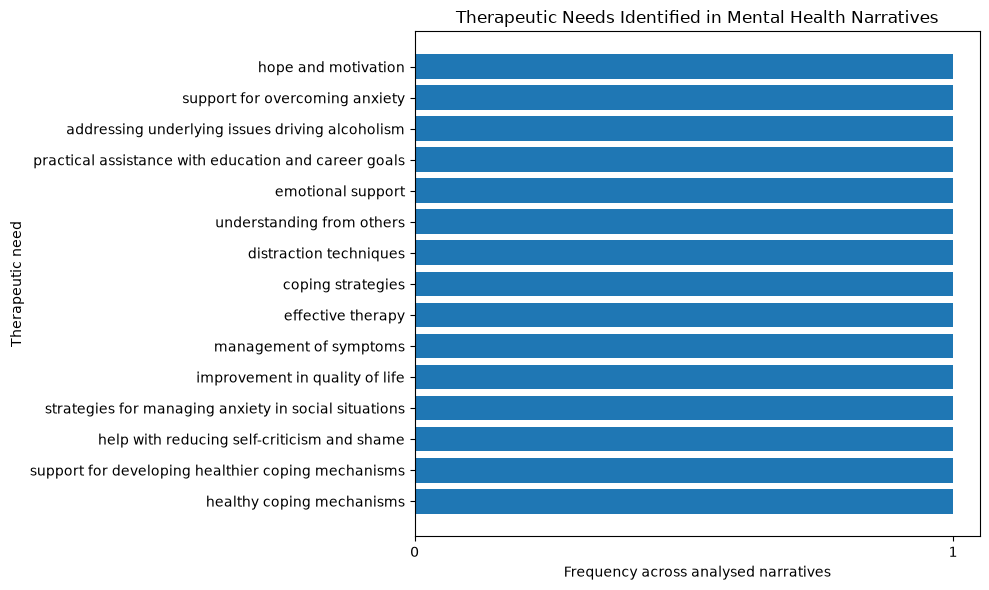

In [93]:
# therapeutic needs

plot_frequencies(

    need_counts,

    title=(
        "Therapeutic Needs Identified in Mental Health Narratives"
    ),

    y_label=(
        "Therapeutic need"
    ),

    filename=(
        "identified_therapeutic_needs.png"
    ),

    number_to_show=15
)

In [94]:
# challenges

identified_challenges = []


for case in results:

    narrative = case.get(
        "narrative"
    )

    if narrative is None:
        continue

    case_challenges = narrative.get(
        "challenges",
        []
    )

    identified_challenges.extend(
        case_challenges
    )


challenge_counts = Counter(
    identified_challenges
)


print("Most frequent challenges:\n")

for challenge, frequency in challenge_counts.most_common(20):

    print(
        frequency,
        "-",
        challenge
    )

Most frequent challenges:

2 - panic attacks
1 - lack of future prospects
1 - financial struggles
1 - limited access to education
1 - alcoholism as a coping mechanism
1 - loss of control
1 - deja vu
1 - feeling like life is ending soon
1 - debilitating panic disorder
1 - vomiting
1 - loss of enjoyment in life
1 - managing anxiety through routine
1 - avoiding triggers (alcohol)
1 - overthinking
1 - social anxiety
1 - managing anxiety
1 - developing trust
1 - coping with social situations
1 - dependence on alcohol
1 - self-care


NameError: name 'FIGURE_DIR' is not defined

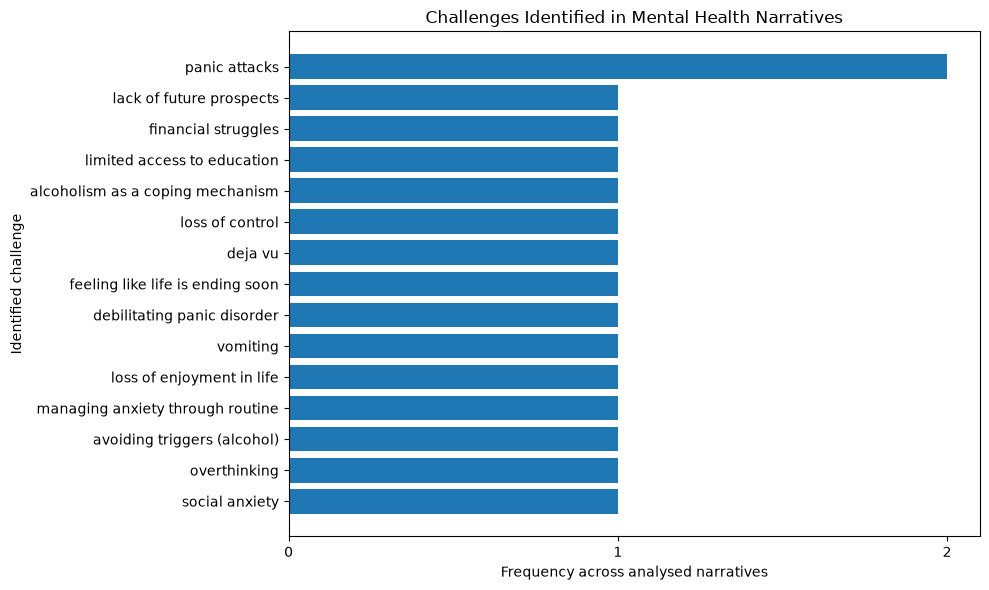

In [96]:
# visualize

plot_frequencies(

    challenge_counts,

    title=(
        "Challenges Identified in Mental Health Narratives"
    ),

    y_label=(
        "Identified challenge"
    ),

    filename=(
        "identified_challenges.png"
    ),

    number_to_show=15
)